# Lab 04 - Hybrid Search and Reciprocal Rank Fusion (RRF)

**Knowledge base:** `knowledge_base/03_retrieval/05_hybrid_search.md`

**Concepts:** Hybrid search · RRF formula · K hyperparameter · Beta weighting · Combining incompatible scores

Hybrid search is the production standard. This lab builds it from the two retrievers you
already have and shows exactly how RRF merges their ranked lists.

---

## Setup

In [1]:
import numpy as np
import math
from collections import defaultdict
from rank_bm25 import BM25Okapi
from sentence_transformers import SentenceTransformer

MODEL_NAME = "BAAI/bge-base-en-v1.5"
print("Loading embedding model...")
model = SentenceTransformer(MODEL_NAME)
print("✅ Ready")

def cosine_similarity(v1, matrix):
    v1 = np.array(v1, dtype=np.float32).ravel()
    M  = np.atleast_2d(np.array(matrix, dtype=np.float32))
    v1_norm = np.linalg.norm(v1)
    M_norms = np.linalg.norm(M, axis=1)
    denom   = v1_norm * M_norms
    return (M @ v1 / np.where(denom == 0, 1.0, denom)).tolist()

Loading embedding model...


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

✅ Ready


---
## 1 - The problem: two ranked lists on incompatible scales

After keyword search and semantic search, you have two ranked lists.
The scores are **not comparable** - BM25 scores are unbounded; cosine scores are in [−1, 1].

You cannot simply average them. You need a ranking algorithm that uses **position, not score**.

In [2]:
# Build both retrievers over the same corpus
corpus = [
    "BM25 is a keyword-based probabilistic ranking algorithm for information retrieval.",
    "Semantic search uses dense vector embeddings to find documents by meaning.",
    "Hybrid search combines keyword and semantic retrieval for better results.",
    "Cosine similarity is the dominant metric in high-dimensional semantic spaces.",
    "The Suez Canal connects the Red Sea to the Mediterranean Sea and is 193 km long.",
    "Reciprocal Rank Fusion merges multiple ranked lists using document rank position.",
    "Metadata filtering excludes documents based on boolean attribute conditions.",
    "Precision@K is the fraction of top-K retrieved documents that are relevant.",
    "Recall@K is the fraction of all relevant documents that appear in the top-K results.",
    "Embeddings are learned representations that place semantically similar text near each other.",
    "BM25 handles exact keyword matches well but fails on synonyms and paraphrases.",
    "Sentence transformers are the standard model family for producing text embeddings.",
]

# BM25 retriever
bm25 = BM25Okapi([doc.lower().split() for doc in corpus])

# Embed corpus for semantic search
print("Embedding corpus...")
corpus_embs = model.encode(corpus)
print(f"✅ Corpus embedded: {corpus_embs.shape}")

Embedding corpus...
✅ Corpus embedded: (12, 768)


In [3]:
query = "How does hybrid retrieval work?"

# Keyword scores (BM25)
bm25_scores = bm25.get_scores(query.lower().split())
bm25_ranked = sorted(range(len(corpus)), key=lambda i: bm25_scores[i], reverse=True)

# Semantic scores (cosine)
query_emb   = model.encode(query)
sem_scores  = cosine_similarity(query_emb, corpus_embs)
sem_ranked  = sorted(range(len(corpus)), key=lambda i: sem_scores[i], reverse=True)

print(f"Query: '{query}'\n")
print("BM25 top-5:    " + " | ".join([f"[{i}] {corpus[i][:35]}..." for i in bm25_ranked[:5]]))
print()
print("Semantic top-5:" + " | ".join([f"[{i}] {corpus[i][:35]}..." for i in sem_ranked[:5]]))
print()
print(f"BM25 score range:     {bm25_scores.min():.3f} to {bm25_scores.max():.3f}")
print(f"Semantic score range: {min(sem_scores):.3f} to {max(sem_scores):.3f}")
print()
print("The two score scales are incompatible - you cannot directly average them.")

Query: 'How does hybrid retrieval work?'

BM25 top-5:    [2] Hybrid search combines keyword and ... | [0] BM25 is a keyword-based probabilist... | [1] Semantic search uses dense vector e... | [3] Cosine similarity is the dominant m... | [4] The Suez Canal connects the Red Sea...

Semantic top-5:[2] Hybrid search combines keyword and ... | [1] Semantic search uses dense vector e... | [0] BM25 is a keyword-based probabilist... | [5] Reciprocal Rank Fusion merges multi... | [6] Metadata filtering excludes documen...

BM25 score range:     0.000 to 4.315
Semantic score range: 0.334 to 0.770

The two score scales are incompatible - you cannot directly average them.


---
## 2 - Reciprocal Rank Fusion (RRF)

RRF uses the **rank position** of each document in each list, not the raw score.
This makes it robust to different score scales.

$$\text{RRF}(d) = \frac{1}{K + \text{rank}_{\text{keyword}}(d)} + \frac{1}{K + \text{rank}_{\text{semantic}}(d)}$$

- `K` is a smoothing constant. `K=0` gives the top-ranked document a massive advantage.
  `K=60` (the default) gives more balanced contribution from all ranks.
- A document ranked 1st in both lists gets the highest possible score.
- A document ranked 1st in only one list still scores well.

In [4]:
def reciprocal_rank_fusion(ranked_lists: list, K: int = 60) -> list:
    '''
    Merge multiple ranked document lists using Reciprocal Rank Fusion.

    Args:
        ranked_lists: List of ranked lists, each containing document indices in rank order.
        K:            Smoothing constant. Higher K = more balanced across ranks.

    Returns:
        List of (rrf_score, doc_index) tuples sorted by RRF score descending.
    '''
    scores = defaultdict(float)
    for ranked in ranked_lists:
        for rank, doc_idx in enumerate(ranked):
            scores[doc_idx] += 1.0 / (K + rank + 1)   # rank is 0-indexed, so +1
    return sorted(scores.items(), key=lambda x: x[1], reverse=True)


# Merge the two ranked lists
hybrid_results = reciprocal_rank_fusion([bm25_ranked, sem_ranked], K=60)

print(f"Query: '{query}'\n")
print("Hybrid (RRF) top-5:")
for doc_idx, rrf_score in hybrid_results[:5]:
    bm25_rank = bm25_ranked.index(doc_idx) + 1
    sem_rank  = sem_ranked.index(doc_idx) + 1
    print(f"  [RRF={rrf_score:.5f}] BM25 rank={bm25_rank:2d} | Sem rank={sem_rank:2d} | {corpus[doc_idx][:65]}...")

Query: 'How does hybrid retrieval work?'

Hybrid (RRF) top-5:
  [RRF=0.03279] BM25 rank= 1 | Sem rank= 1 | Hybrid search combines keyword and semantic retrieval for better ...
  [RRF=0.03200] BM25 rank= 2 | Sem rank= 3 | BM25 is a keyword-based probabilistic ranking algorithm for infor...
  [RRF=0.03200] BM25 rank= 3 | Sem rank= 2 | Semantic search uses dense vector embeddings to find documents by...
  [RRF=0.03078] BM25 rank= 4 | Sem rank= 6 | Cosine similarity is the dominant metric in high-dimensional sema...
  [RRF=0.03078] BM25 rank= 6 | Sem rank= 4 | Reciprocal Rank Fusion merges multiple ranked lists using documen...


---
## 3 - The effect of K

K controls how much the top-ranked document dominates.
Small K: the single best document scores much higher than second place.
Large K: scores are more spread out - documents at rank 10 still contribute meaningfully.

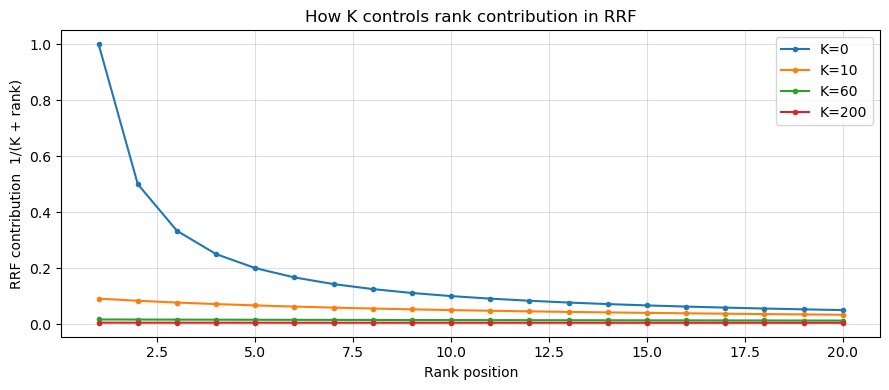


K=0:   rank 1 dominates overwhelmingly
K=60:  balanced - the default for most production systems
K=200: very flat - all ranks contribute almost equally


In [5]:
import matplotlib.pyplot as plt

ranks = list(range(1, 21))
fig, ax = plt.subplots(figsize=(9, 4))

for K in [0, 10, 60, 200]:
    rrf_vals = [1.0 / (K + r) for r in ranks]
    ax.plot(ranks, rrf_vals, marker=".", label=f"K={K}")

ax.set_xlabel("Rank position")
ax.set_ylabel("RRF contribution  1/(K + rank)")
ax.set_title("How K controls rank contribution in RRF")
ax.legend()
ax.grid(True, alpha=0.4)
plt.tight_layout()
plt.show()

print()
print("K=0:   rank 1 dominates overwhelmingly")
print("K=60:  balanced - the default for most production systems")
print("K=200: very flat - all ranks contribute almost equally")

---
## 4 - Full hybrid search function

Wrap everything into a single function you can drop into your RAG pipeline.

In [6]:
def hybrid_search(query: str, corpus: list, corpus_embs: np.ndarray,
                   bm25_model, top_k: int = 5, K: int = 60,
                   beta: float = 0.7) -> list:
    '''
    Hybrid search: BM25 + semantic + RRF fusion.

    Args:
        query:       The search query.
        corpus:      List of document strings.
        corpus_embs: Pre-computed embedding matrix.
        bm25_model:  Fitted BM25Okapi instance.
        top_k:       Number of results to return.
        K:           RRF smoothing constant.
        beta:        Weight for semantic list (0 = keyword only, 1 = semantic only).
                     Beta controls how many documents from each list enter RRF.
                     With beta=0.7, semantic candidates get priority in list size.

    Returns:
        List of (rrf_score, document, doc_index) tuples.
    '''
    n = len(corpus)

    # BM25 ranked list
    bm25_scores = bm25_model.get_scores(query.lower().split())
    bm25_ranked = sorted(range(n), key=lambda i: bm25_scores[i], reverse=True)

    # Semantic ranked list
    q_emb      = model.encode(query)
    sem_scores = cosine_similarity(q_emb, corpus_embs)
    sem_ranked = sorted(range(n), key=lambda i: sem_scores[i], reverse=True)

    # RRF fusion
    rrf_scores = defaultdict(float)
    for rank, idx in enumerate(bm25_ranked):
        rrf_scores[idx] += (1 - beta) / (K + rank + 1)
    for rank, idx in enumerate(sem_ranked):
        rrf_scores[idx] += beta / (K + rank + 1)

    ranked = sorted(rrf_scores.items(), key=lambda x: x[1], reverse=True)
    return [(score, corpus[idx], idx) for idx, score in ranked[:top_k]]


# Test on several query types
test_queries = [
    ("BM25 keyword ranking",         "technical term - keyword should help"),
    ("finding text by its meaning",  "paraphrase - semantic should help"),
    ("combining retrieval methods",  "conceptual - both should help"),
]

for q, description in test_queries:
    print(f"\nQuery: '{q}'  ({description})")
    results = hybrid_search(q, corpus, corpus_embs, bm25, top_k=3)
    for score, doc, _ in results:
        print(f"  [{score:.5f}] {doc[:75]}...")


Query: 'BM25 keyword ranking'  (technical term - keyword should help)
  [0.01639] BM25 is a keyword-based probabilistic ranking algorithm for information ret...
  [0.01613] BM25 handles exact keyword matches well but fails on synonyms and paraphras...
  [0.01587] Hybrid search combines keyword and semantic retrieval for better results....

Query: 'finding text by its meaning'  (paraphrase - semantic should help)
  [0.01639] Semantic search uses dense vector embeddings to find documents by meaning....
  [0.01591] Hybrid search combines keyword and semantic retrieval for better results....
  [0.01587] Embeddings are learned representations that place semantically similar text...

Query: 'combining retrieval methods'  (conceptual - both should help)
  [0.01639] Hybrid search combines keyword and semantic retrieval for better results....
  [0.01613] BM25 is a keyword-based probabilistic ranking algorithm for information ret...
  [0.01587] Semantic search uses dense vector embeddings to fi

---
## 5 - Exercise: compare pure BM25, pure semantic, and hybrid

For the query below, run all three retrievers and compare their top-3 results.
Then explain which retriever performed best and why.

In [ ]:
exercise_query = "What metric tells you how many relevant documents were found?"

print(f"Query: '{exercise_query}'\n")

# BM25 only
print("BM25 only:")
bm25_scores_ex = bm25.get_scores(exercise_query.lower().split())
bm25_ranked_ex = sorted(range(len(corpus)), key=lambda i: bm25_scores_ex[i], reverse=True)
for i in bm25_ranked_ex[:3]:
    print(f"  [bm25={bm25_scores_ex[i]:.4f}] {corpus[i]}")

print()

# Semantic only
print("Semantic only:")
q_emb_ex = model.encode(exercise_query)
sem_scores_ex = cosine_similarity(q_emb_ex, corpus_embs)
sem_ranked_ex = sorted(range(len(corpus)), key=lambda i: sem_scores_ex[i], reverse=True)
for i in sem_ranked_ex[:3]:
    print(f"  [cos={sem_scores_ex[i]:.4f}] {corpus[i]}")

print()

# Hybrid
print("Hybrid (RRF):")
hybrid_ex = hybrid_search(exercise_query, corpus, corpus_embs, bm25, top_k=3)
for score, doc, _ in hybrid_ex:
    print(f"  [rrf={score:.5f}] {doc}")

print()
print("YOUR ANALYSIS: which retriever performed best for this query and why?")
# Write your analysis as a comment below
# 

---
**Lab 04 complete.**

You have implemented the full hybrid retriever used in production RAG systems.
The key insight: RRF uses rank position, not raw score, making it robust
to the incompatible scales of keyword and semantic scoring.

**Next:** `lab05_retrieval_evaluation.ipynb` - measure how good your retriever is.